# Insurance Cost Prediction - End-to-End Project

## 1. Introduction

This notebook covers the full lifecycle of the Insurance Cost Prediction project. We will start with a deep dive into the data through **Exploratory Data Analysis (EDA)**, followed by feature engineering, and finally a rigorous comparison of machine learning models to identify the best performer for our production API.

**Objective:** Predict `PremiumPrice` based on health and demographic factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, 
    confusion_matrix, classification_report, 
    roc_auc_score, roc_curve, f1_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

In [2]:
df = pd.read_csv('../data/insurance.csv')
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


## 3. Exploratory Data Analysis (EDA)
Before modeling, we must understand the data structure, distributions, and relationships.

In [3]:
# General Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [4]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,986.0,41.745436,13.963371,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,0.419878,0.493789,0.0,0.0,0.0,1.0,1.0
BloodPressureProblems,986.0,0.468560,0.499264,0.0,0.0,0.0,1.0,1.0
AnyTransplants,986.0,0.055781,0.229615,0.0,0.0,0.0,0.0,1.0
AnyChronicDiseases,986.0,0.180527,0.384821,0.0,0.0,0.0,0.0,1.0
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,0.215010,0.411038,0.0,0.0,0.0,0.0,1.0
HistoryOfCancerInFamily,986.0,0.117647,0.322353,0.0,0.0,0.0,0.0,1.0
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0


In [5]:
# Missing Values Check
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64


### 3.1 Distribution of Premium Price (Target)

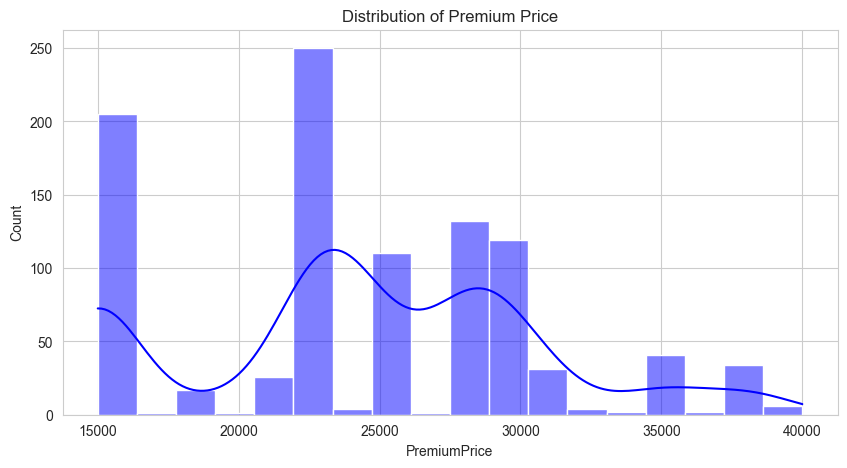

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['PremiumPrice'], kde=True, color='blue')
plt.title('Distribution of Premium Price')
plt.show()

### 3.2 Feature Analysis

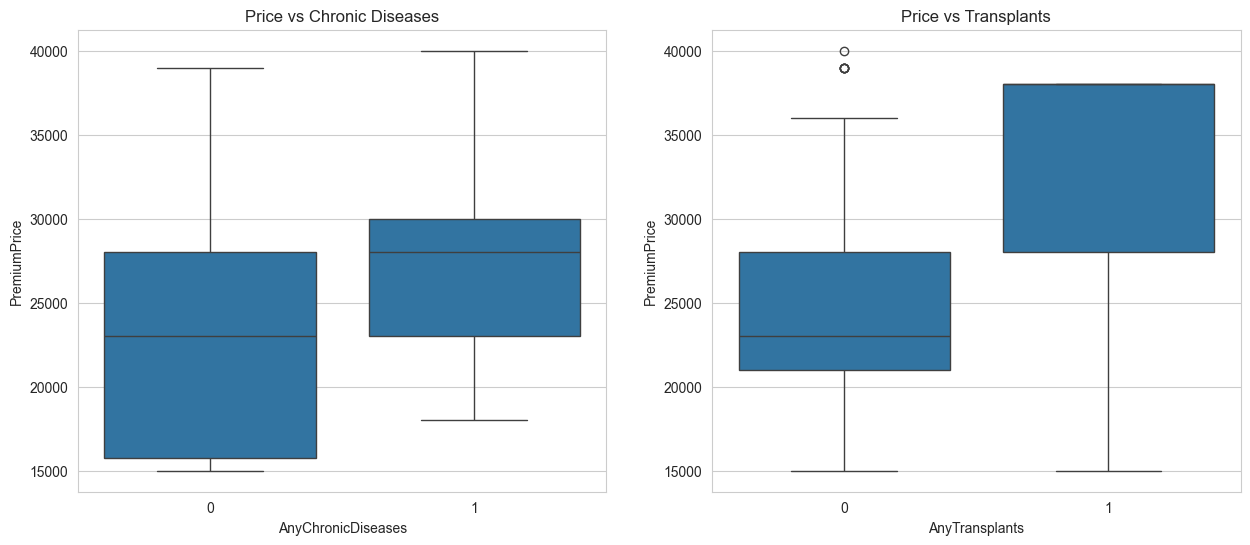

In [7]:
# Impact of Chronic Diseases and Transplants on Price
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='AnyChronicDiseases', y='PremiumPrice', data=df, ax=axes[0])
axes[0].set_title('Price vs Chronic Diseases')

sns.boxplot(x='AnyTransplants', y='PremiumPrice', data=df, ax=axes[1])
axes[1].set_title('Price vs Transplants')

plt.show()

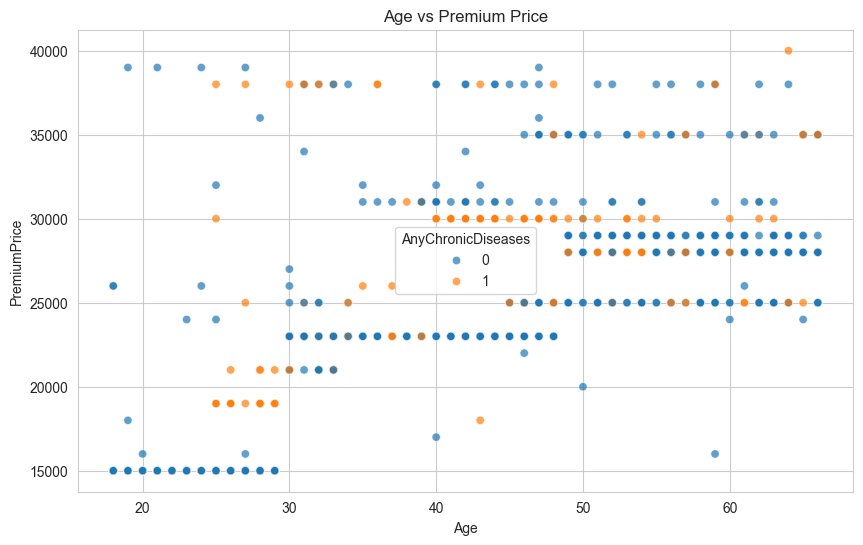

In [8]:
# Age vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='PremiumPrice', data=df, hue='AnyChronicDiseases', alpha=0.7)
plt.title('Age vs Premium Price')
plt.show()

### 3.3 Correlation Analysis

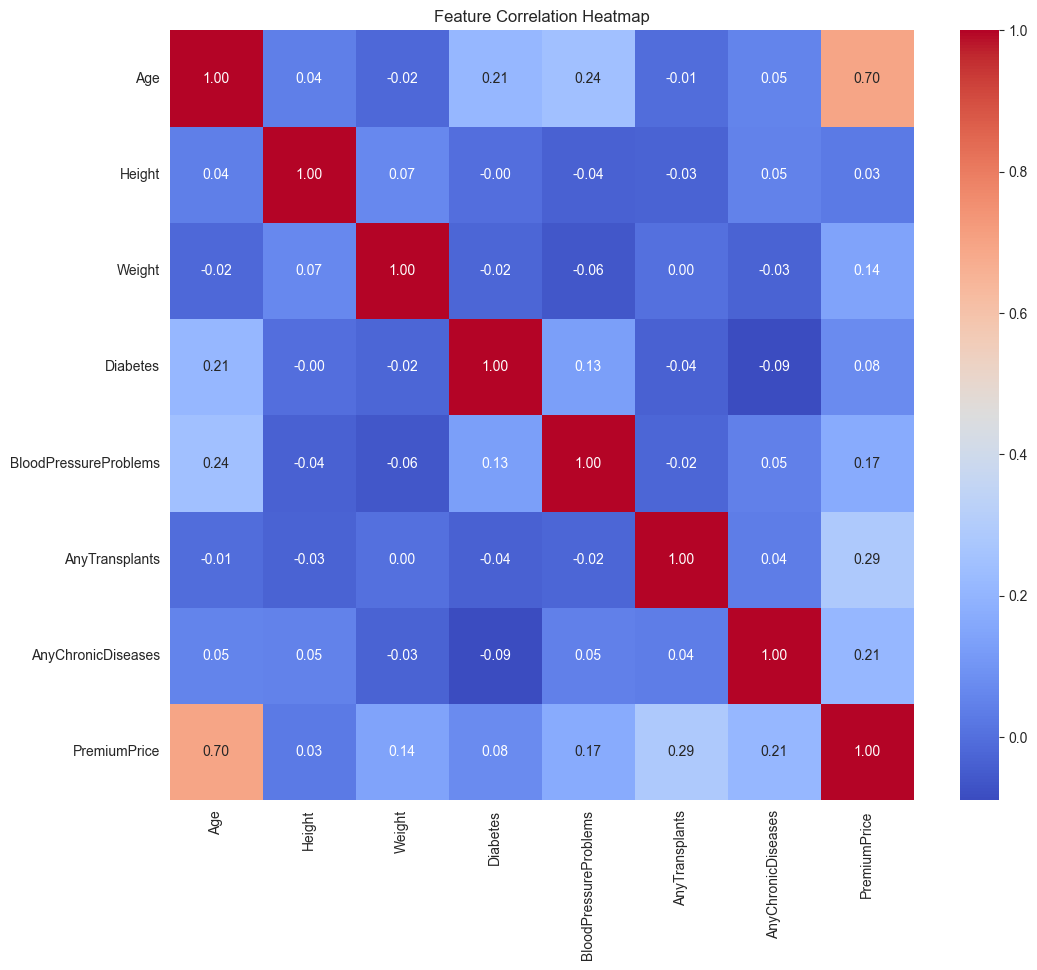

In [9]:
plt.figure(figsize=(12, 10))
features_for_corr = ['Age', 'Height', 'Weight', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'PremiumPrice']
corr = df[features_for_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Feature Engineering & Preprocessing
Based on domain knowledge, **BMI** is a critical factor. We create this feature before modeling.

In [10]:
# Create BMI Feature
df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2

# Check correlation of BMI with Price
print(f"Correlation between BMI and Price: {df['BMI'].corr(df['PremiumPrice']):.4f}")

Correlation between BMI and Price: 0.1038


In [11]:
# Define Features and Target
features = ['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 
            'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 
            'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'BMI']
target = 'PremiumPrice'

X = df[features]
y = df[target]

# Perform Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Numerical Features
scaler = StandardScaler()
numerical_cols = ['Age', 'Height', 'Weight', 'BMI', 'NumberOfMajorSurgeries']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("Data Splitting and Scaling Complete.")

Data Splitting and Scaling Complete.


## 5. Model Selection & Comparison
We will test multiple regression algorithms to find the best baseline and optimal model.

,Model,R2 Score,MAE
2,Random Forest,0.893781,1014.292929
3,XGBoost,0.827134,1341.172607
0,Linear Regression,0.713646,2586.181710
1,Decision Tree,0.623250,1287.878788


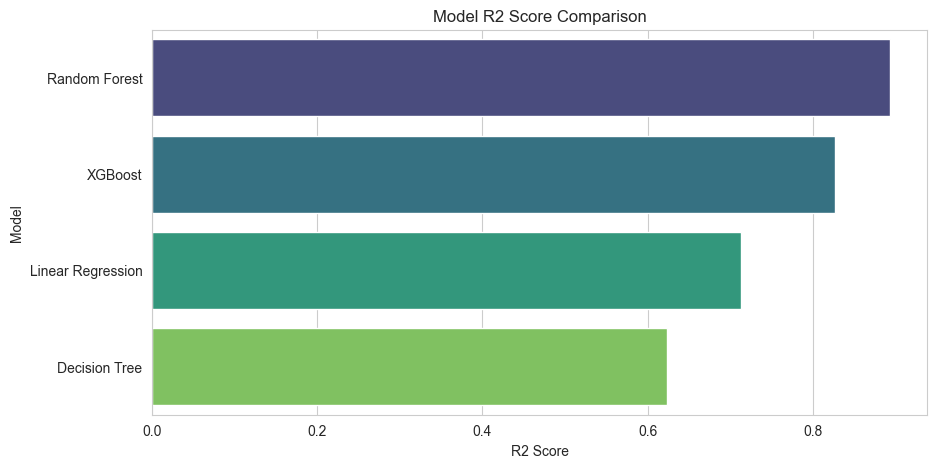

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({"Model": name, "R2 Score": r2, "MAE": mae})

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
display(results_df)

plt.figure(figsize=(10, 5))
sns.barplot(x='R2 Score', y='Model', data=results_df, palette='viridis')
plt.title('Model R2 Score Comparison')
plt.show()

## 6. Optimization (XGBoost)
XGBoost shows the best potential. We will tune its hyperparameters to squeeze out maximum performance.

In [13]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(xgb, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(f"Best Params: {grid.best_params_}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits


Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


## 7. Final Evaluation
Testing the tuned regression model on unseen data.

Final R2 Score: 0.8482
Final MAE: 1392.85


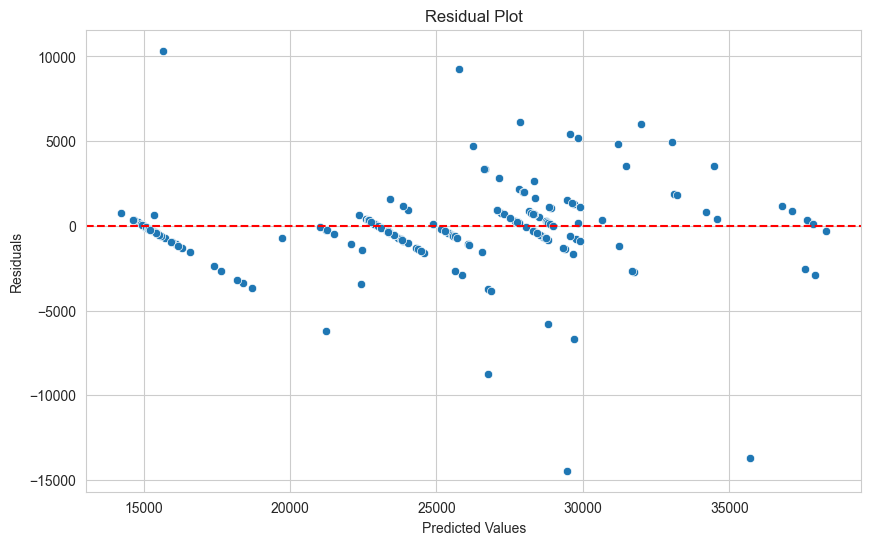

In [14]:
final_pred = best_model.predict(X_test_scaled)
final_r2 = r2_score(y_test, final_pred)
final_mae = mean_absolute_error(y_test, final_pred)

print(f"Final R2 Score: {final_r2:.4f}")
print(f"Final MAE: {final_mae:.2f}")

# Residual Plot
plt.figure(figsize=(10, 6))
residuals = y_test - final_pred
sns.scatterplot(x=final_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

## 8. Classification Analysis: Risk Tier Prediction

In addition to predicting the exact cost, we can classify customers into **Low** or **High** risk categories to better understand the model's ability to separate premium tiers.

- **Target**: High Premium (1) if Price > Median, else Low Premium (0).
- **Metrics**: Confusion Matrix, ROC-AUC, F1-Score, Recall.

In [15]:
# Define Binary Target based on Median Price
threshold = df['PremiumPrice'].median()
y_class = (df['PremiumPrice'] > threshold).astype(int)

# Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Scale Features
X_train_c_scaled = X_train_c.copy()
X_test_c_scaled = X_test_c.copy()
X_train_c_scaled[numerical_cols] = scaler.fit_transform(X_train_c[numerical_cols])
X_test_c_scaled[numerical_cols] = scaler.transform(X_test_c[numerical_cols])

print(f"Classification Threshold (Median Price): {threshold}")
print(f"Class Balance:\n{y_class.value_counts(normalize=True)}")

Classification Threshold (Median Price): 23000.0
Class Balance:
PremiumPrice
0    0.507099
1    0.492901
Name: proportion, dtype: float64


In [16]:
# Train Classifier
clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
clf.fit(X_train_c_scaled, y_train_c)

# Predict
y_pred_class = clf.predict(X_test_c_scaled)
y_prob = clf.predict_proba(X_test_c_scaled)[:, 1]

# Metrics
conf_mat = confusion_matrix(y_test_c, y_pred_class)
accuracy = accuracy_score(y_test_c, y_pred_class)
f1 = f1_score(y_test_c, y_pred_class)
recall = recall_score(y_test_c, y_pred_class)
roc_auc = roc_auc_score(y_test_c, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_class))

Accuracy: 0.9697
F1 Score: 0.9703
Recall: 0.9703
ROC-AUC: 0.9843

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        97
           1       0.97      0.97      0.97       101

    accuracy                           0.97       198
   macro avg       0.97      0.97      0.97       198
weighted avg       0.97      0.97      0.97       198



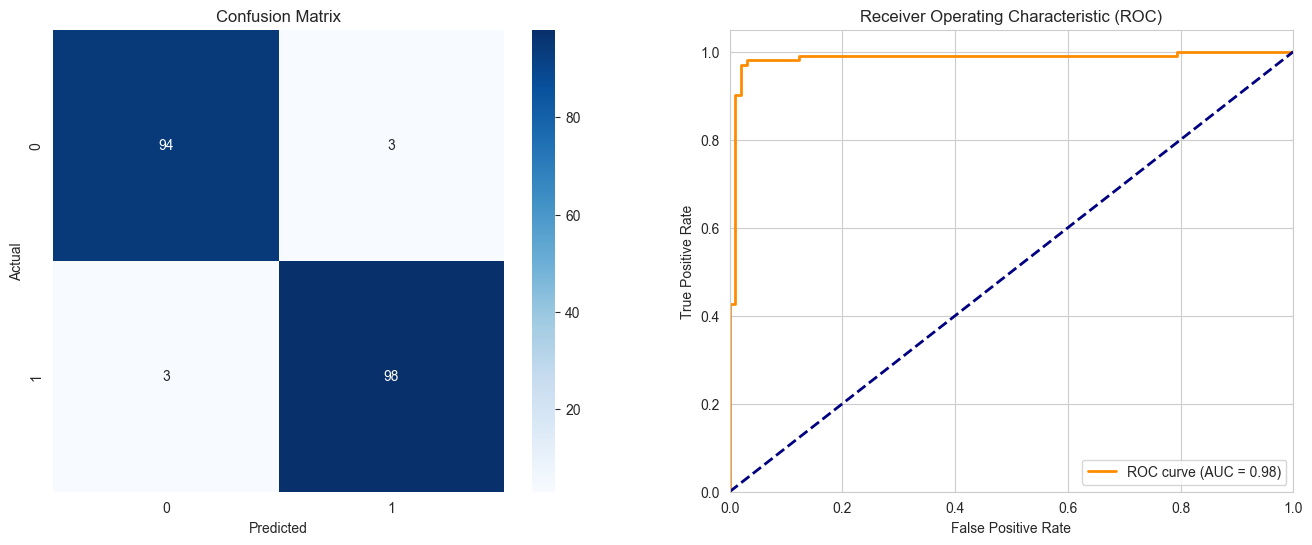

In [17]:
# Visualization: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.show()